# Skyview Aerial Landscape Dataset

# Initial Setup

Outputs taken from the EDA branch.

### Libraries

In [18]:
# Importing Libraries
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Loading Files, Folder, and Data Splits

In [19]:
# Loading data
df = pd.read_csv('outputs/features/image_features.csv')

# Creating directories for saving the models and results
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

metadata_cols = [
    'relative_path', 'class_name', 'label_idx', 'split', 
    'is_human_made', 'is_water_related', 'is_vegetation_related', 
    'urban_density_proxy', 'brightness'
]
feature_cols = [col for col in df.columns if col not in metadata_cols]

# Isolating Splits
train = df[df['split'] == 'train']
val = df[df['split'] == 'val']
test = df[df['split'] == 'test']

train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

X_train = train_df[feature_cols].values
y_train = train_df['class_name'].values

X_val = val_df[feature_cols].values
y_val = val_df['class_name'].values

X_test = test_df[feature_cols].values
y_test = test_df['class_name'].values

print(f"Data Loaded -> Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Data Loaded -> Train: 9597 | Val: 1200 | Test: 1200


# Model: PCA

In [20]:
# Scaling features on training data
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitting PCA Model
print("Applying PCA (95% variance threshold)...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original Feature Space: {X_train_scaled.shape[1]} dimensions")
print(f"Reduced PCA Space: {X_train_pca.shape[1]} dimensions")



Scaling features...
Applying PCA (95% variance threshold)...
Original Feature Space: 43 dimensions
Reduced PCA Space: 18 dimensions


In [21]:
# Exporting the fitted scaler and PCA model for the SVM phase
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(pca, 'models/pca_model.pkl')
print("Scaler and PCA models saved to 'models/' directory.")

Scaler and PCA models saved to 'models/' directory.


### Visualization: PCA Variance Plot

Generating PCA Variance Plot...


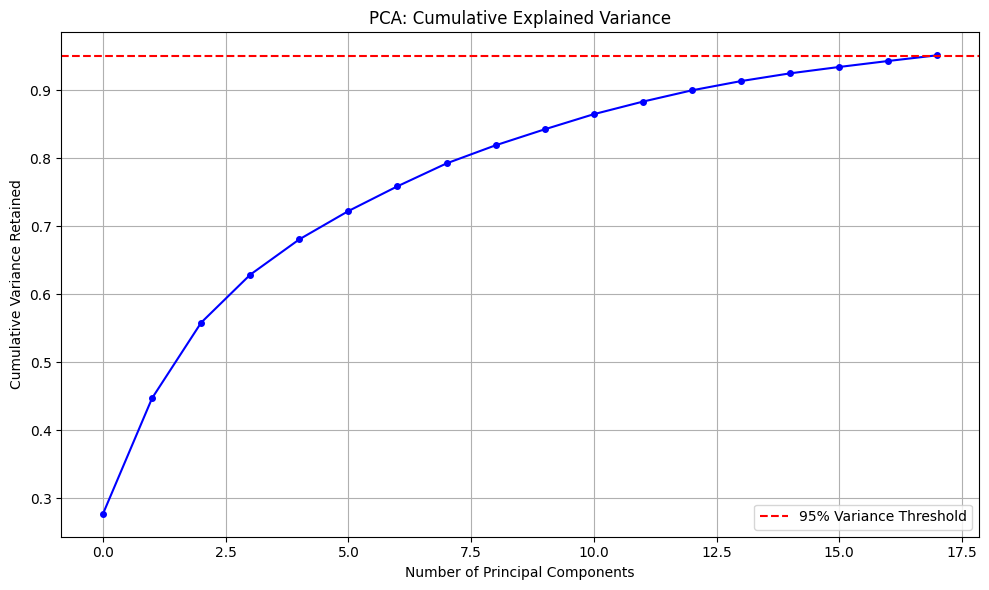

In [ ]:
print("Generating PCA Variance Plot...")
plt.figure(figsize=(10, 6))

# Calculating cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumulative_variance, marker='o', markersize=4, linestyle='-', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')

plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Retained')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Saving the plot
plt.savefig('results/pca_variance_plot.png', dpi=150)
plt.show()
plt.close()

### Visualization: 2D PCA Scatter Plot

Generating 2D PCA Scatter Plot...


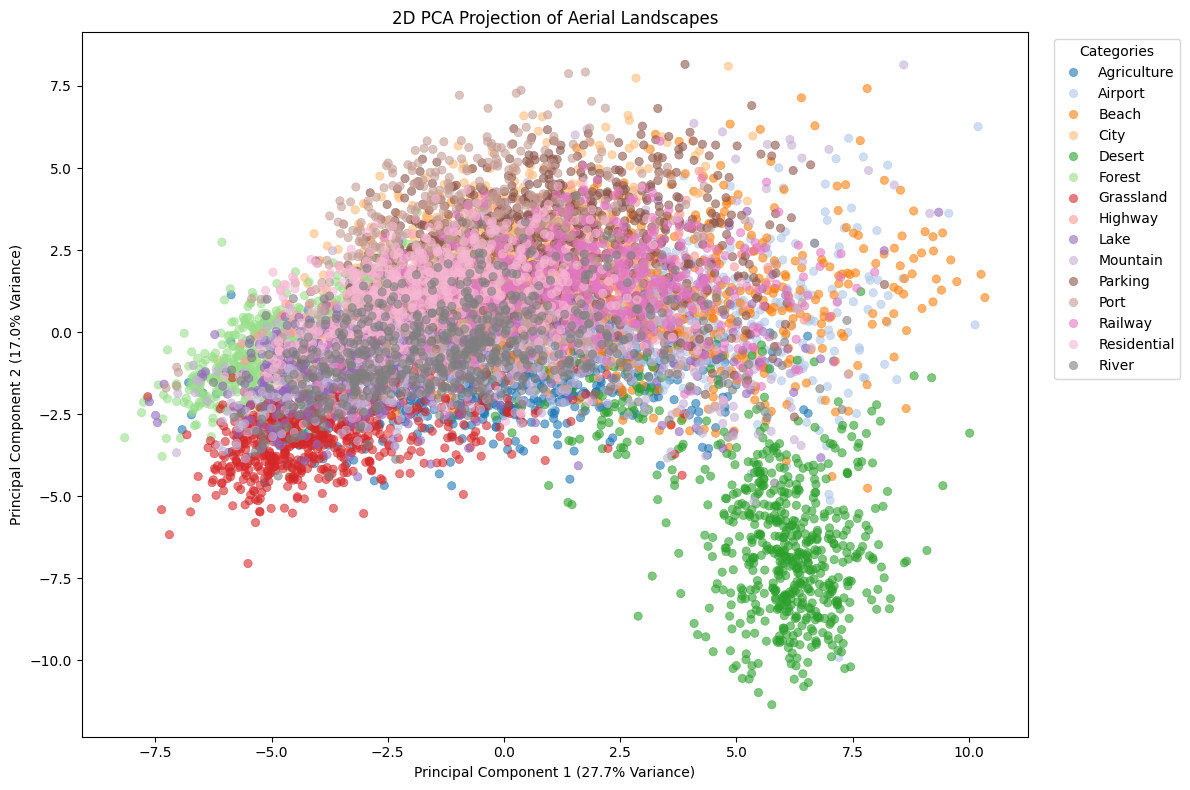

PCA visualizations successfully saved to the 'results/' directory.


In [23]:
print("Generating 2D PCA Scatter Plot...")

# Creating a DataFrame using the first two Principal Components
pca_df = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'Class': y_train
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Class', 
    palette='tab20', 
    alpha=0.6, 
    edgecolor=None
)

# Addding dynamic labels showing exactly how much variance the first 2 components hold
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.title('2D PCA Projection of Aerial Landscapes')
plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% Variance)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Categories')
plt.tight_layout()

# Saving the plot
plt.savefig('results/pca_2d_scatter.png', dpi=150)
plt.show()
plt.close()

print("PCA visualizations successfully saved to the 'results/' directory.")

# Model: SVM

### Hyperparameters

In [27]:
# Adding the validation set for hyperparameter tuning
X_val_pca = pca.transform(scaler.transform(X_val))

print("\nInitiating SVM Grid Search...")

# Setting Parameters for Grid Search
param_grid = [
    # Grid 1: Linear Kernel (only tests C)
    {'kernel': ['linear'], 
     'C': [0.1, 1, 10, 100]},
    
    # Grid 2: RBF Kernel (tests C and gamma)
    {'kernel': ['rbf'], 
     'C': [0.1, 1, 10, 100], 
     'gamma': ['scale', 'auto', 0.01, 0.001]},
    
    # Grid 3: Polynomial Kernel (tests C, degree, and gamma)
    {'kernel': ['poly'], 
     'C': [0.1, 1, 10], 
     'degree': [2, 3], 
     'gamma': ['scale', 'auto']},
    
    # Grid 4: Sigmoid Kernel
    {'kernel': ['sigmoid'], 
     'C': [0.1, 1, 10], 
     'gamma': ['scale', 'auto'],
     'coef0': [0.0, 0.1, 1.0]}
]

# Generating SVM model
svm = SVC(class_weight='balanced', random_state=42)

# Starting grid search - applying 3-fold cross-validation on training
grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train)

# Displaying the best Parameters
best_svm = grid_search.best_estimator_
print(f"\nOptimal SVM Parameters: {grid_search.best_params_}")



Initiating SVM Grid Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Optimal SVM Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


### Evaluation

In [29]:
# Sorting class_names
class_names = sorted(df['class_name'].unique())

# Checking performance on Validation split
print("\nEvaluating on Validation split...")
y_val_pred = best_svm.predict(X_val_pca)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Generating predictions on Test split
print("\nEvaluating on Test split...")
y_test_pred = best_svm.predict(X_test_pca)

# Dislaying Classification Report
print("\n--- Classification Report (Test Set) ---")
report = classification_report(y_test, y_test_pred, target_names=class_names)
print(report)

# Export the text report
with open('results/svm_classification_report.txt', 'w') as f:
    f.write(f"Optimal Parameters: {grid_search.best_params_}\n")
    f.write(f"Validation Accuracy: {val_accuracy * 100:.2f}%\n\n")
    f.write("Test Set Classification Report:\n")
    f.write(report)



Evaluating on Validation split...
Validation Accuracy: 72.42%

Evaluating on Test split...

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

 Agriculture       0.65      0.76      0.70        80
     Airport       0.56      0.57      0.57        80
       Beach       0.79      0.70      0.74        80
        City       0.71      0.76      0.73        80
      Desert       0.89      0.89      0.89        80
      Forest       0.86      0.91      0.88        80
   Grassland       0.84      0.88      0.86        80
     Highway       0.55      0.45      0.49        80
        Lake       0.75      0.70      0.72        80
    Mountain       0.67      0.71      0.69        80
     Parking       0.92      0.90      0.91        80
        Port       0.85      0.82      0.84        80
     Railway       0.58      0.62      0.60        80
 Residential       0.81      0.82      0.82        80
       River       0.51      0.45      0.48        80



### Confusion Matrix

Generating Confusion Matrix...
Saved: results/svm_confusion_matrix.png


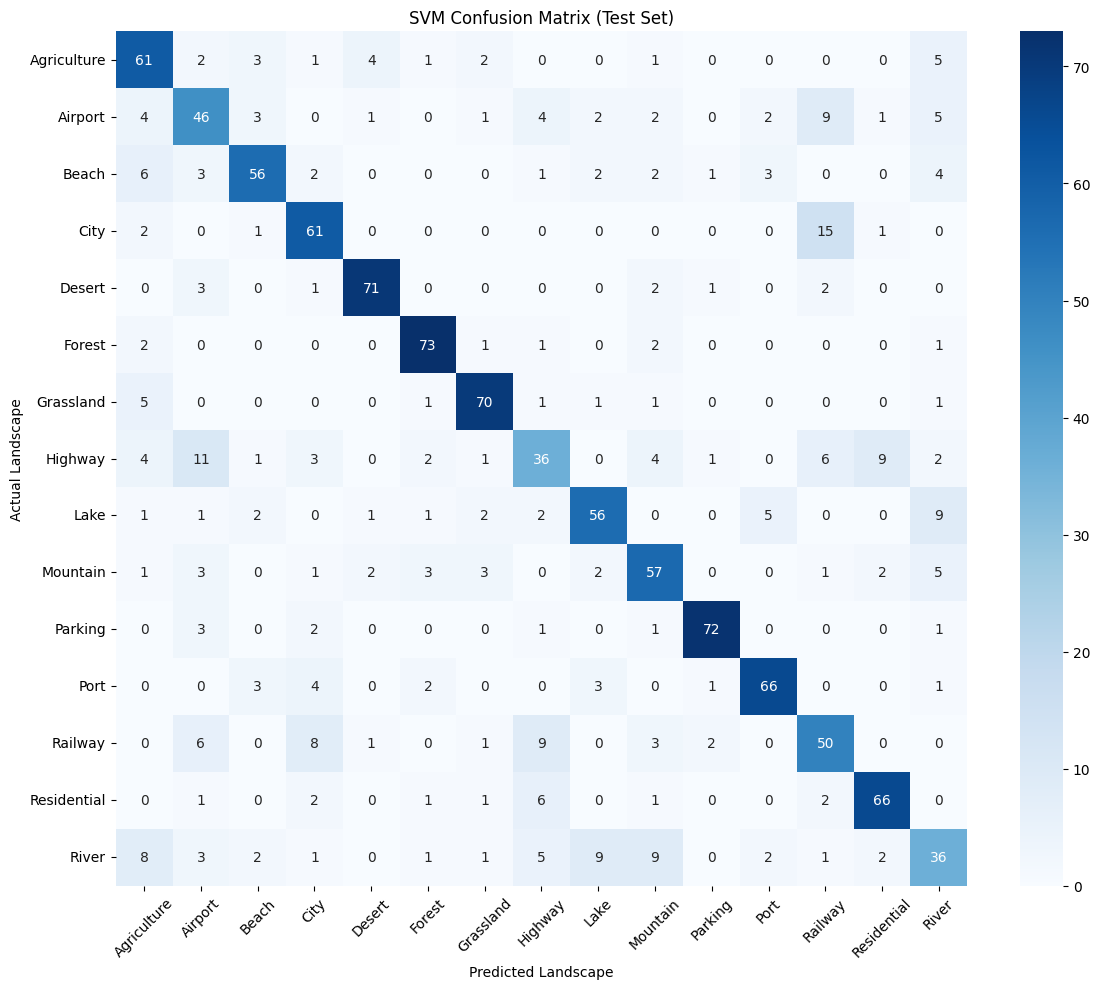

Best SVM model successfully exported to 'models/best_svm.pkl'.


In [30]:
print("Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_test_pred, labels=class_names)

# Generating heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('SVM Confusion Matrix (Test Set)')
plt.ylabel('Actual Landscape')
plt.xlabel('Predicted Landscape')
plt.xticks(rotation=45)
plt.tight_layout()

# Displaying the plot
plt.savefig('results/svm_confusion_matrix.png', dpi=150)
print("Saved: results/svm_confusion_matrix.png")
plt.show() 
plt.close()

# Final Model export
joblib.dump(best_svm, 'models/best_svm.pkl')
print("Best SVM model successfully exported to 'models/best_svm.pkl'.")